# HW2 — Digital FIR Filter (Python Analysis)

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# Parameter Setting
N  = 25       # tap 數
M  = (N-1)//2 # = 12，中心偏移
Ts = 1/6      # 截止頻率參數
bits = np.arange(9, 20) # 9 到 16
threshold = 2 ** -11   # RMSE 門檻（a=11）

# h[n] = sinc(n·Ts)，n = [-12, 12]
h = np.zeros(N)
for i in range(N):
    n = i - M
    t = n * Ts
    h[i] = 1.0 if n == 0 else np.sin(np.pi * t) / (np.pi * t)

h = h / np.sum(h) # Normalize 不知道能不能用，助教沒說 ! 

# Quantization Function
def quantize(z, b):
    return np.floor(z * 2**b) / 2**b

## Step 1 — Filter Design

用 sinc 函數建立 25-tap 低通 FIR 濾波器，畫出脈衝響應與頻率響應。

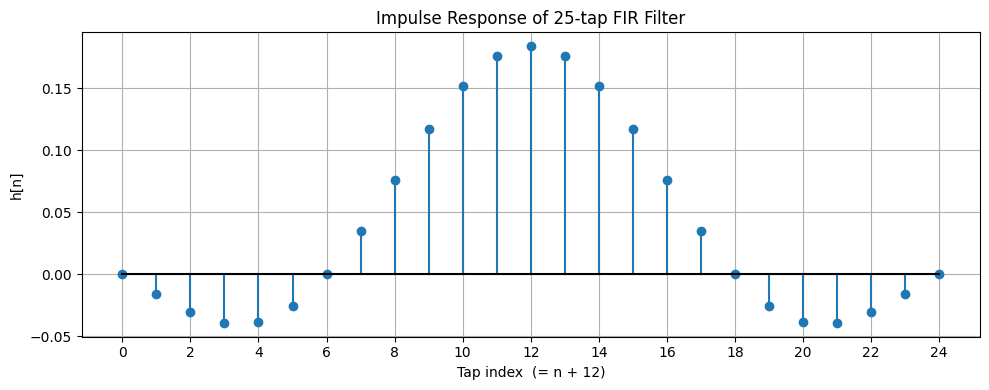

In [108]:
# 脈衝響應
plt.figure(figsize=(10, 4))
plt.stem(range(N), h, basefmt='k-')
plt.title("Impulse Response of 25-tap FIR Filter")
plt.xlabel("Tap index  (= n + 12)")
plt.ylabel("h[n]")
plt.xticks(range(0, N, 2))
plt.grid(True)
plt.tight_layout()
plt.show()

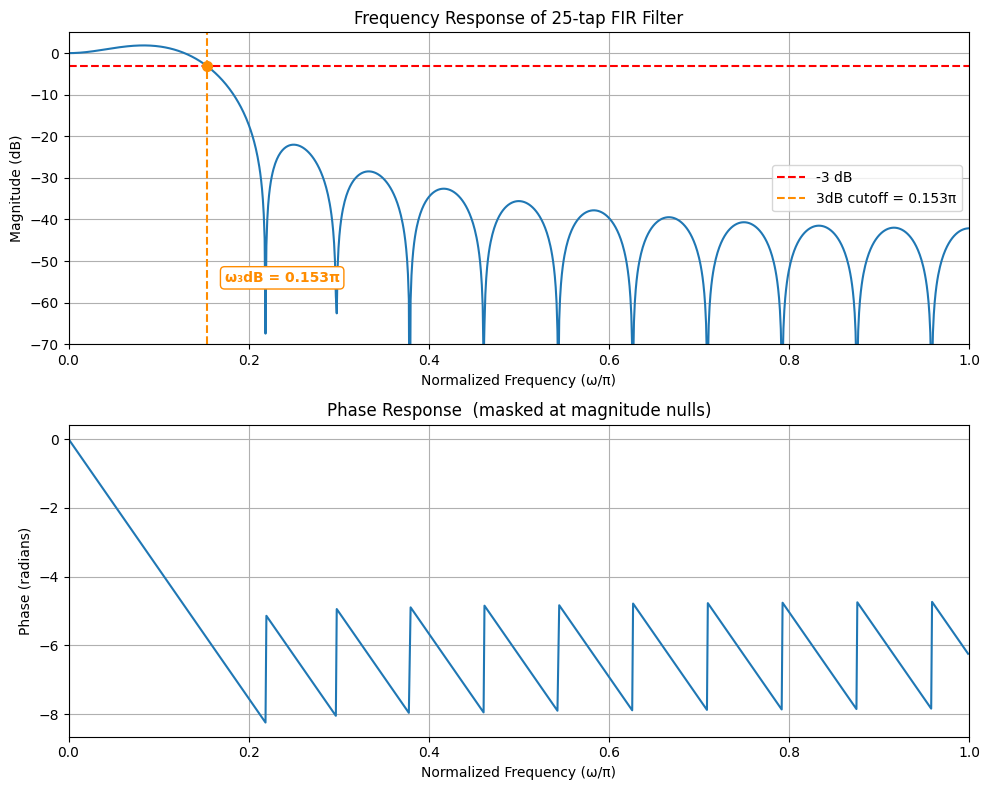

In [110]:
# 頻率響應
w, H = freqz(h, worN=1024)
freq_norm    = w / np.pi
magnitude_dB = 20 * np.log10(np.abs(H) + 1e-12)
phase_rad    = np.unwrap(np.angle(H))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(freq_norm, magnitude_dB)
ax1.set_title("Frequency Response of 25-tap FIR Filter")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_xlabel("Normalized Frequency (ω/π)")
ax1.set_xlim([0, 1])
ax1.set_ylim([-70, 5])

# -3dB 截止點標示
idx_3dB = np.where(magnitude_dB <= -3)[0]
if len(idx_3dB) > 0:
    f_3dB = freq_norm[idx_3dB[0]]
    ax1.axhline(-3, color='red', linestyle='--', linewidth=1.5, label='-3 dB')
    ax1.axvline(f_3dB, color='darkorange', linestyle='--', linewidth=1.5,
                label=f'3dB cutoff = {f_3dB:.3f}π')
    ax1.text(f_3dB + 0.02, -55, f'ω₃dB = {f_3dB:.3f}π',
             color='darkorange', fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='darkorange', boxstyle='round,pad=0.3'))
    ax1.plot(f_3dB, -3, 'o', color='darkorange', markersize=7, zorder=5)
ax1.legend()
ax1.grid(True)

# null 點附近的 phase 不可信，只畫有效區段
valid = np.abs(H) > 1e-4
ax2.plot(freq_norm[valid], phase_rad[valid])
ax2.set_title("Phase Response  (masked at magnitude nulls)")
ax2.set_ylabel("Phase (radians)")
ax2.set_xlabel("Normalized Frequency (ω/π)")
ax2.set_xlim([0, 1])
ax2.grid(True)

plt.tight_layout()
plt.show()

## Step 2 — Evaluate performance 

輸入訊號包含兩個頻率成分：

| 成分 | ω/π | 位置 | 結果 |
|------|-----|------|------|
| sin(−2πn/128) | 0.016 | passband | 通過 |
| −cos(2πn/4) | 0.500 | stopband | 被濾除 |

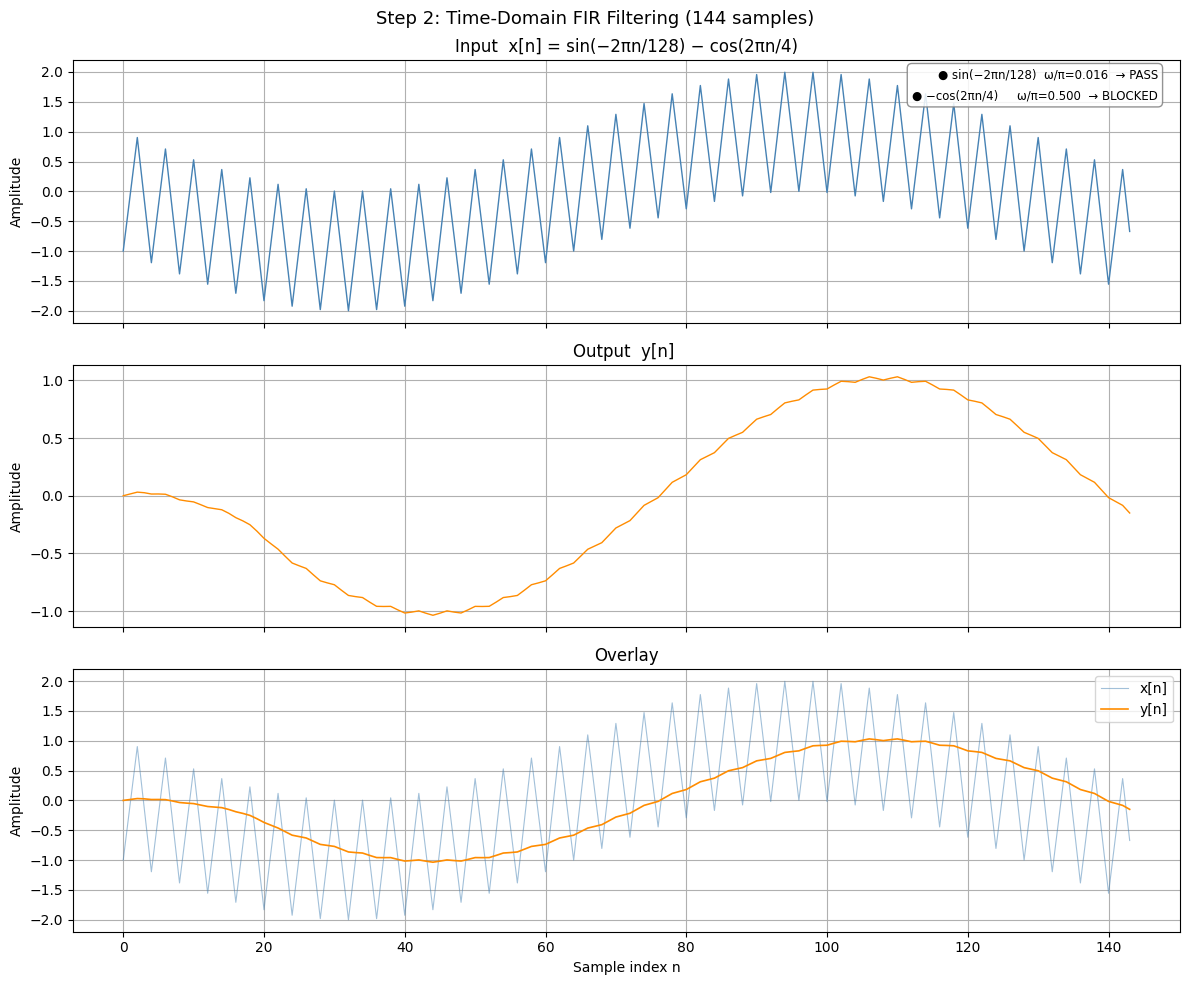

In [111]:
n_idx = np.arange(144)
x = np.sin(-2 * np.pi * n_idx / 128) - np.cos(2 * np.pi * n_idx / 4)

# 線性卷積，取前 144 點（因果濾波器輸出）
y_float = np.convolve(x, h)[:144]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Step 2: Time-Domain FIR Filtering (144 samples)", fontsize=13)

axes[0].plot(n_idx, x, color='steelblue', linewidth=1)
axes[0].set_title("Input  x[n] = sin(−2πn/128) − cos(2πn/4)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)
axes[0].text(0.98, 0.97,
             "● sin(−2πn/128)  ω/π=0.016  → PASS\n● −cos(2πn/4)     ω/π=0.500  → BLOCKED",
             transform=axes[0].transAxes, fontsize=8.5,
             va='top', ha='right',
             bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.4'),
             linespacing=1.8)

axes[1].plot(n_idx, y_float, color='darkorange', linewidth=1)
axes[1].set_title("Output  y[n] ")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

axes[2].plot(n_idx, x,       color='steelblue',  linewidth=0.8, alpha=0.5, label='x[n]')
axes[2].plot(n_idx, y_float, color='darkorange',  linewidth=1.2,            label='y[n]')
axes[2].set_title("Overlay")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Sample index n")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Step 3.A — Find the Best Word-Length after Quantization


  Node A : Word_Length = 14
  Node B : Word_Length = 14
  Node C : Word_Length = 16
  Node D : Word_Length = 18


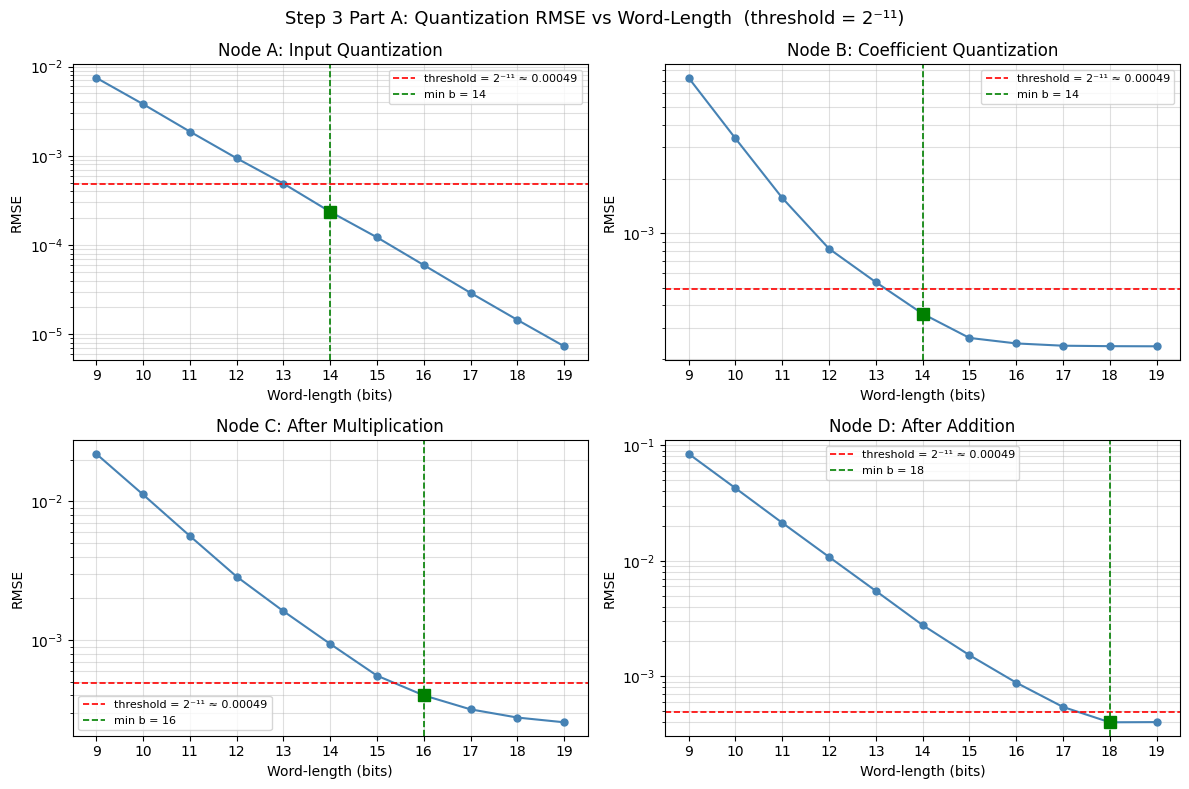

In [112]:
def rmse(y_test):
    return np.sqrt(np.mean((y_float - y_test) ** 2))

def first_pass(errors, thr):
    idx = np.where(errors < thr)[0]
    return bits[idx[0]] if len(idx) > 0 else None


def fir(x_in, h_in, b_mult=None, b_add=None):
    L = len(x_in)
    y_out = np.zeros(L)
    x_pad = np.concatenate([np.zeros(N - 1), x_in])   # zero-padding for causality
    for n in range(L):
        acc = 0.0
        for k in range(N):
            prod = h_in[k] * x_pad[n + N - 1 - k]
            if b_mult is not None:
                prod = quantize(prod, b_mult)
            acc += prod
            if b_add is not None:
                acc = quantize(acc, b_add)
        y_out[n] = acc
    return y_out

rmse_A = []
rmse_B = []
rmse_C = []
rmse_D = []

# Module 1 - Scan Input Word-Lengths
for b in bits:
    int_bits = int(np.floor(np.log2(np.abs(x).max()))) + 2
    x_q = quantize(x, b - int_bits) # 量化 
    y_A = np.convolve(x_q, h)[:144] # 拿量化後的定點數去做捲積
    rmse_A.append(rmse(y_A)) 

rmse_A = np.array(rmse_A)
b_A = first_pass(rmse_A, threshold) # 找出最小符合的 bit

# Module 2 - Scan Coefficient Word-lengths (Fix Input Word-Lengths)
for b in bits:
    int_bits = int(np.floor(np.log2(np.abs(x).max()))) + 2
    x_q = quantize(x, b_A - int_bits) # 量化
    int_bits = int(np.floor(np.log2(np.abs(h).max()))) + 2
    h_q = quantize(h, b - int_bits) # 量化
    y_B = np.convolve(x_q, h_q)[:144] # 拿量化後的定點數去做捲積
    rmse_B.append(rmse(y_B))

rmse_B = np.array(rmse_B)
b_B = first_pass(rmse_B, threshold) # 找出最小符合的 bit

# Module 3 - Scan Word-Lengths after multiplications (Fix Input & Cofficient Word-Lengths)
for b in bits:
    int_bits = int(np.floor(np.log2(np.abs(x).max()))) + 2
    x_q = quantize(x, b_A - int_bits) # 量化
    int_bits = int(np.floor(np.log2(np.abs(h).max()))) + 2
    h_q = quantize(h, b - int_bits) # 量化
    int_bits = int(np.floor(np.log2(np.abs(x_q).max() * np.abs(h_q).max()))) + 2 # 捲積相乘最大值一定是 max(|x|) * max(|h|)
    y_C = fir(x_q, h_q, b_mult=(b-int_bits), b_add=None)
    rmse_C.append(rmse(y_C))

rmse_C = np.array(rmse_C)
b_C = first_pass(rmse_C, threshold) # 找出最小符合的 bit

# Module 4 - Scan Word-lengths after addition (Fix Input & Cofficient Word-Lengths and after multiplication)
for b in bits:
    int_bits = int(np.floor(np.log2(np.abs(x).max()))) + 2
    x_q = quantize(x, b_A - int_bits) # 量化
    int_bits = int(np.floor(np.log2(np.abs(h).max()))) + 2
    h_q = quantize(h, b - int_bits) # 量化
    int_bits = int(np.floor(np.log2(np.abs(x_q).max() * np.abs(h_q).max()))) + 2 # 捲積相乘最大值一定是 max(|x|) * max(|h|)
    y_C = fir(x_q, h_q, b_mult=(b_C-int_bits), b_add=None) # 相加的最大值就直接來找捲積輸出最大值
    int_bit_for_add = int(np.floor(np.log2(np.abs(y_C).max()))) + 2
    y_D = fir(x_q, h_q, b_mult=(b_C-int_bits), b_add=(b-int_bit_for_add)) # 相加的最大值就直接找捲積輸出最大值
    rmse_D.append(rmse(y_D))

rmse_D = np.array(rmse_D)
b_D = first_pass(rmse_D, threshold) # 找出最小符合的 bit

print(f"  Node A : Word_Length = {b_A}")
print(f"  Node B : Word_Length = {b_B}")
print(f"  Node C : Word_Length = {b_C}")
print(f"  Node D : Word_Length = {b_D}")


# 畫圖 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Step 3 Part A: Quantization RMSE vs Word-Length  (threshold = 2⁻¹¹)", fontsize=13)

configs = [
    (axes[0, 0], rmse_A, b_A, "Node A: Input Quantization"),
    (axes[0, 1], rmse_B, b_B, "Node B: Coefficient Quantization"),
    (axes[1, 0], rmse_C, b_C, "Node C: After Multiplication"),
    (axes[1, 1], rmse_D, b_D, "Node D: After Addition"),
]

for ax, errors, b_pass, title in configs:
    ax.semilogy(bits, errors, 'o-', color='steelblue', linewidth=1.5, markersize=5)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'threshold = 2⁻¹¹ ≈ {threshold:.5f}')
    if b_pass is not None:
        ax.axvline(b_pass, color='green', linestyle='--', linewidth=1.2,
                   label=f'min b = {b_pass}')
        ax.plot(b_pass, errors[b_pass - 9], 's', color='green', markersize=8, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("Word-length (bits)")
    ax.set_ylabel("RMSE")
    ax.set_xticks(bits)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

## Step 3.B — Find the Best Word-Length after Quantization


In [123]:

# 把剛剛找到的 Fixed-Point 參數全部帶進去算出 y_fixed
int_bits = int(np.floor(np.log2(np.abs(x).max()))) + 2
x_q = quantize(x, b_A - int_bits) # 量化
int_bits = int(np.floor(np.log2(np.abs(h).max()))) + 2
h_q = quantize(h, b - int_bits) # 量化
int_bits = int(np.floor(np.log2(np.abs(x_q).max() * np.abs(h_q).max()))) + 2 # 捲積相乘最大值一定是 max(|x|) * max(|h|)
y_C = fir(x_q, h_q, b_mult=(b_C-int_bits), b_add=None) # 相加的最大值就直接來找捲積輸出最大值
int_bit_for_add = int(np.floor(np.log2(np.abs(y_C).max()))) + 2
y_fixed = fir(x_q, h_q, b_mult=(b_C-int_bits), b_add=(b_D-int_bit_for_add)) 
error = y_fixed - y_float 
rmse_combined = np.sqrt(np.mean(error ** 2))

print(f"\n=== Combined Fixed-point RMSE ===")
print(f"  RMSE          = {rmse_combined:.8f}")
print(f"  Threshold 2⁻¹¹= {threshold:.8f}")
print(f"{'Pass' if rmse_combined < threshold else 'Fail'}")

# 固定點頻率響應（用量化後的 h_q）
w, H_float = freqz(h,   worN=2048)
w, H_fixed = freqz(h_q, worN=2048)
freq_norm = w / np.pi

mag_float_dB = 20 * np.log10(np.abs(H_float) + 1e-12)
mag_fixed_dB = 20 * np.log10(np.abs(H_fixed) + 1e-12)

# passband 範圍（ω/π < 0.201）
passband_mask = freq_norm < 0.201
mag_err_dB = mag_fixed_dB[passband_mask] - mag_float_dB[passband_mask]

print(f"\n=== Passband Magnitude Error ===")
print(f"  Max error in passband = {np.max(np.abs(mag_err_dB)):.4f} dB")




=== Combined Fixed-point RMSE ===
  RMSE          = 0.00040085
  Threshold 2⁻¹¹= 0.00048828
Pass

=== Passband Magnitude Error ===
  Max error in passband = 0.0002 dB


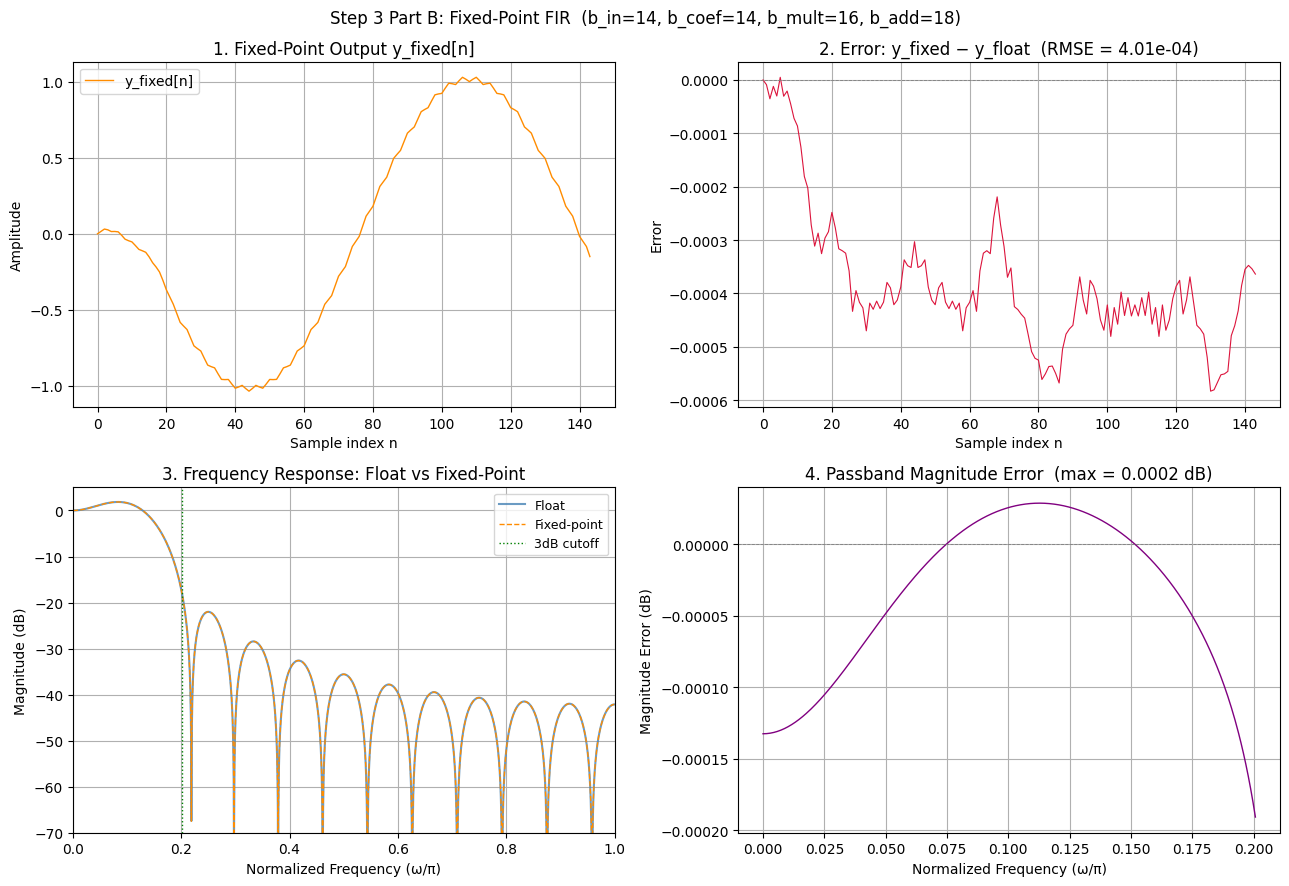

In [124]:
# 畫圖 

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"Step 3 Part B: Fixed-Point FIR  "
    f"(b_in={b_A}, b_coef={b_B}, b_mult={b_C}, b_add={b_D})",
    fontsize=12)

#  子圖 1：Fixed-point 時域輸出 
axes[0, 0].plot(n_idx, y_fixed, color='darkorange', linewidth=1, label='y_fixed[n]')
axes[0, 0].set_title("1. Fixed-Point Output y_fixed[n]")
axes[0, 0].set_xlabel("Sample index n")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()
axes[0, 0].grid(True)

#  子圖 2：誤差 y_fixed - y_float 
axes[0, 1].plot(n_idx, error, color='crimson', linewidth=0.8)
axes[0, 1].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axes[0, 1].set_title(f"2. Error: y_fixed − y_float  (RMSE = {rmse_combined:.2e})")
axes[0, 1].set_xlabel("Sample index n")
axes[0, 1].set_ylabel("Error")
axes[0, 1].grid(True)

#  子圖 3：頻率響應對比 
axes[1, 0].plot(freq_norm, mag_float_dB, color='steelblue',
                linewidth=1.5, label='Float', alpha=0.8)
axes[1, 0].plot(freq_norm, mag_fixed_dB, color='darkorange',
                linewidth=1, linestyle='--', label='Fixed-point')
axes[1, 0].axvline(0.201, color='green', linestyle=':', linewidth=1, label='3dB cutoff')
axes[1, 0].set_title("3. Frequency Response: Float vs Fixed-Point")
axes[1, 0].set_xlabel("Normalized Frequency (ω/π)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([-70, 5])
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True)

#  子圖 4：Passband magnitude 誤差 
axes[1, 1].plot(freq_norm[passband_mask], mag_err_dB,
                color='purple', linewidth=1)
axes[1, 1].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axes[1, 1].set_title(
    f"4. Passband Magnitude Error  (max = {np.max(np.abs(mag_err_dB)):.4f} dB)")
axes[1, 1].set_xlabel("Normalized Frequency (ω/π)")
axes[1, 1].set_ylabel("Magnitude Error (dB)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()